# Aktivasyon Fonksiyonlarının ve Düzenleştirme Tekniklerinin Eğitim Dinamiklerine Etkisi

**Gelişmiş Analiz:** Ağırlık İlkleme, Regularization (L1/L2), Batch Normalization ve Hata Analizi

Bu notebook şu konuları kapsar:

* **Teorik Temel (Logits & Softmax)** – Ham çıktıların olasılığa dönüşümü ve Temperature Scaling analizi
* **Ağırlık İlkleme Analizi** – He (Kaiming) ve Xavier initialization yöntemlerinin karşılaştırması
* **Düzenleştirme (Regularization)** – Overfitting'i önlemek için L1, L2 (Weight Decay) ve Label Smoothing etkileri
* **Batch Normalization** – Dahili kovaryans kayması çözümü ve eğitim hızı optimizasyonu
* **Learning Rate Scheduler** – Eğitim sürecinde dinamik öğrenme oranı yönetimi
* **Gradyan Sönümlenmesi Teorisi** – Sigmoid türevi üzerinden matematiksel öğrenme kaybı ispatı
* **Confusion Matrix** – Modelin en çok karıştırdığı rakam çiftlerinin hata analizi
* **Dead ReLU Problemi** – Adam optimizer ve aktivasyon bölgelerinin sönümlenme analizi


In [16]:
# =========================
# IMPORTS
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================
# SETUP
# =========================
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# DATA
# =========================
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

Using device: cuda


## 1. Model Mimarisi: Batch Normalization ile DeepMLP

### Batch Normalization Nedir?

Her tam bağlantılı (Linear) katmandan sonra ve aktivasyon fonksiyonundan hemen önce eklenen **BatchNorm1d** katmanıdır. Temel avantajları şunlardır:

* **Dahili Kovaryans Kayması (Internal Covariate Shift):** Eğitim sırasında her katmanın girdi dağılımının değişmesini engelleyerek daha kararlı bir eğitim sağlar.

* **Gradyan Akışı:** Aktivasyon değerlerini normalize ederek gradyanların çok küçülmesini (Vanishing Gradient) veya patlamasını (Exploding Gradient) engeller.

* **Düzenleştirici Etki:** Kendi içinde hafif bir gürültü eklediği için Dropout ihtiyacını azaltabilir ve aşırı öğrenmeyi (Overfitting) zorlaştırır.


In [17]:
# =========================
# MODEL – WITH BATCH NORMALIZATION
# =========================
class DeepMLP(nn.Module):
    def __init__(self, activation_fn, use_dropout=True, use_batchnorm=False):
        super().__init__()
        self.flatten = nn.Flatten()
        self.use_batchnorm = use_batchnorm

        self.layers = nn.ModuleList([
            nn.Linear(28*28, 128),
            nn.Linear(128, 128),
            nn.Linear(128, 128),
            nn.Linear(128, 128),
        ])

        # Batch Normalization katmanları (her Linear sonrası, aktivasyondan önce)
        if use_batchnorm:
            self.batchnorms = nn.ModuleList([
                nn.BatchNorm1d(128),
                nn.BatchNorm1d(128),
                nn.BatchNorm1d(128),
                nn.BatchNorm1d(128),
            ])

        self.activation = activation_fn
        self.dropout = nn.Dropout(0.2) if use_dropout else nn.Identity()
        self.out = nn.Linear(128, 10)

    def forward(self, x, store_activations=False):
        x = self.flatten(x)
        self._acts = []

        for i, layer in enumerate(self.layers):
            x = layer(x)
            # Batch Norm: Linear'dan sonra, aktivasyondan önce
            if self.use_batchnorm:
                x = self.batchnorms[i](x)
            x = self.activation(x)
            if store_activations:
                self._acts.append(x.detach().cpu())
            if i < 3:
                x = self.dropout(x)

        return self.out(x)

## 2. Ağırlık İlkleme (Weight Initialization) Analizi

### Neden Önemli?

Bir sinir ağı eğitilmeye başladığında, ağırlıklar rastgele atanır. Ancak bu "rastgelelik" kontrolsüz olursa iki temel sorun ortaya çıkar:

* **Vanishing Gradients (Gradyan Sönümlenmesi)**: Ağırlıklar çok küçük başlarsa, katmanlar ilerledikçe sinyal yok olur.
* **Exploding Gradients (Gradyan Patlaması)**: Ağırlıklar çok büyük başlarsa, değerler sonsuza gider ve model öğrenemez.

### İlkleme Yöntemleri

**Xavier (Glorot) Initialization**:

* Kullanım: Sigmoid ve Tanh gibi simetrik aktivasyon fonksiyonları için tasarlanmıştır.
* Mantık: Giriş ve çıkış katmanlarındaki varyansın eşit olmasını hedefler. Varyansı $2 / (fan_in + fan_out)$ olarak belirleyerek sinyalin derin ağlarda kaybolmasını engeller.

**He (Kaiming) Initialization**:

* Kullanım: ReLU ve türevleri (LeakyReLU) için optimize edilmiştir.
* Mantık: ReLU fonksiyonu negatif değerleri sıfırladığı için varyansın yarısını yok eder. He ilklemesi, bu kaybı telafi etmek için varyansı $2 / fan_in$ kullanarak sinyali iki kat daha güçlü tutar.


In [18]:
# =========================
# WEIGHT INITIALIZATION FUNCTIONS
# =========================
def apply_kaiming_init(model):
    """He (Kaiming) initialization – ReLU/LeakyReLU için ideal"""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model

def apply_xavier_init(model):
    """Xavier initialization – Sigmoid/Tanh için ideal"""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model

print("Weight initialization functions tanımlandı.")
print("  - kaiming_normal_: ReLU / LeakyReLU için")
print("  - xavier_normal_:  Sigmoid / Tanh için")

Weight initialization functions tanımlandı.
  - kaiming_normal_: ReLU / LeakyReLU için
  - xavier_normal_:  Sigmoid / Tanh için


## 3. Dead ReLU Analizi ve Eğitim Dinamikleri

### Dead ReLU Problemi

ReLU aktivasyonu, girdisi negatif olduğunda tam olarak 0 üretir. Adam gibi agresif optimizatörler ağırlıkları öyle güncelleyebilir ki; nöron her zaman negatif bölgede kalır, gradyan akışı kesilir ve nöron "ölür".

Çözüm: LeakyReLU kullanarak negatif bölgeye küçük bir eğim ($0.01$) eklemek, gradyanın hayatta kalmasını sağlar.

### Eğitim Stratejisi

Hazırlanan train_model fonksiyonu şu gelişmiş teknikleri içerir:

L1 Regularization: Sadece ağırlıklara (weights) uygulanarak gereksiz bağlantıları eler (sparsity).

Label Smoothing: Modelin sınıflardan %100 emin olmasını engelleyerek genelleme yeteneğini artırır.

Gradient Clipping: Gradyan normunu $1.0$ ile sınırlayarak patlayan gradyanları (exploding gradients) önler.

LR Scheduler: StepLR ile eğitim ilerledikçe öğrenme oranını düşürerek stabil bir yakınsama sağlar.


In [19]:
# =========================
# DEAD NEURON ANALYSIS
# =========================
def compute_dead_neurons(model, loader, n_batches=3):
    model.eval()
    sums = None

    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= n_batches:
                break
            x = x.to(device)
            _ = model(x, store_activations=True)
            acts = model._acts

            if sums is None:
                sums = [torch.zeros(a.shape[1]) for a in acts]

            for j, a in enumerate(acts):
                sums[j] += a.abs().sum(dim=0)

    dead = [(s == 0).sum().item() for s in sums]
    total = sum(s.numel() for s in sums)
    return sum(dead)/total * 100

# =========================
# TRAIN FUNCTION (Optimize Edilmiş: L1 Sadece Ağırlıklara Uygulanır)
# =========================
def train_model(name, activation, optimizer_type="sgd", lr=0.01,
                weight_decay=0.0, l1_lambda=0.0, label_smoothing=0.0,
                use_dropout=True, use_batchnorm=False, init_type="default",
                use_scheduler=False):

    model = DeepMLP(activation, use_dropout, use_batchnorm).to(device)

    # ── Ağırlık İlkleme ──────────────────────────────────────────
    if init_type == "kaiming":
        apply_kaiming_init(model)
    elif init_type == "xavier":
        apply_xavier_init(model)

    # ── Optimizer ────────────────────────────────────────────────
    # L2 Regularization, 'weight_decay' parametresi ile optimizer içinde halledilir.
    if optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # ── Learning Rate Scheduler ──────────────────────
    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    # Label Smoothing: Modelin aşırı özgüvenini (overconfidence) engeller.
    loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    losses, accs = [], []
    grad_norms = []
    lr_history = []

    for epoch in tqdm(range(10), desc=name):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(x)

            # 1. Ana Kayıp (Loss) Hesaplaması (CrossEntropy + Label Smoothing)
            loss = loss_fn(pred, y)

            # 2. GÜNCEL L1 Regularization (Sadece Ağırlıklar / Weights)
            # Bias parametrelerini (named_parameters içinde 'bias' geçenler) cezalandırmıyoruz.
            if l1_lambda > 0:
                l1_penalty = sum(p.abs().sum() for name, p in model.named_parameters() if 'weight' in name)
                loss += l1_lambda * l1_penalty

            loss.backward()

            # Gradient norm takibi
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.norm().item()
            grad_norms.append(total_norm)

            # Gradient clipping: Patlayan gradyanları engellemek için
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            total_loss += loss.item()

        losses.append(total_loss / len(train_loader))

        if scheduler:
            lr_history.append(scheduler.get_last_lr()[0])
            scheduler.step()
        else:
            lr_history.append(lr)

        # TEST (Doğruluk Ölçümü)
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x).argmax(1)
                correct += (pred == y).sum().item()
                total += y.size(0)

        accs.append(100 * correct / total)

    # Eğitim sonunda "Ölü ReLU" yüzdesini hesapla
    dead_pct = compute_dead_neurons(model, train_loader)

    return {
        "loss": losses,
        "acc": accs,
        "grad": grad_norms,
        "dead": dead_pct,
        "lr_history": lr_history,
        "model": model
    }


## Deneyler ve Metodoloji Analizi

Bu bölümde, modelin başarısını ve genelleme yeteneğini artırmak için kullanılan farklı teknikler gruplandırılarak test edilmiştir:

* Temel Aktivasyonlar: ReLU, Sigmoid, Tanh ve LeakyReLU'nun ham performans karşılaştırması.

* Düzenleştirme (Regularization): L1 ve L2 (Weight Decay) cezalarının ağırlıklar üzerindeki kısıtlayıcı etkisi.

* Label Smoothing: Modelin aşırı özgüvenini (overconfidence) engelleyerek genelleme kapasitesine etkisi.

Optimizasyon ve İlkleme:

* He vs. Xavier: Aktivasyon fonksiyonuna uygun ağırlık başlatma stratejileri.

* Batch Normalization: Eğitim hızı ve gradyan akışı üzerindeki stabilize edici etkisi.

* LR Scheduler: Dinamik öğrenme oranının yakınsama kalitesine katkısı.


Adam_Scheduler: 100%|██████████| 10/10 [01:41<00:00, 10.13s/it]


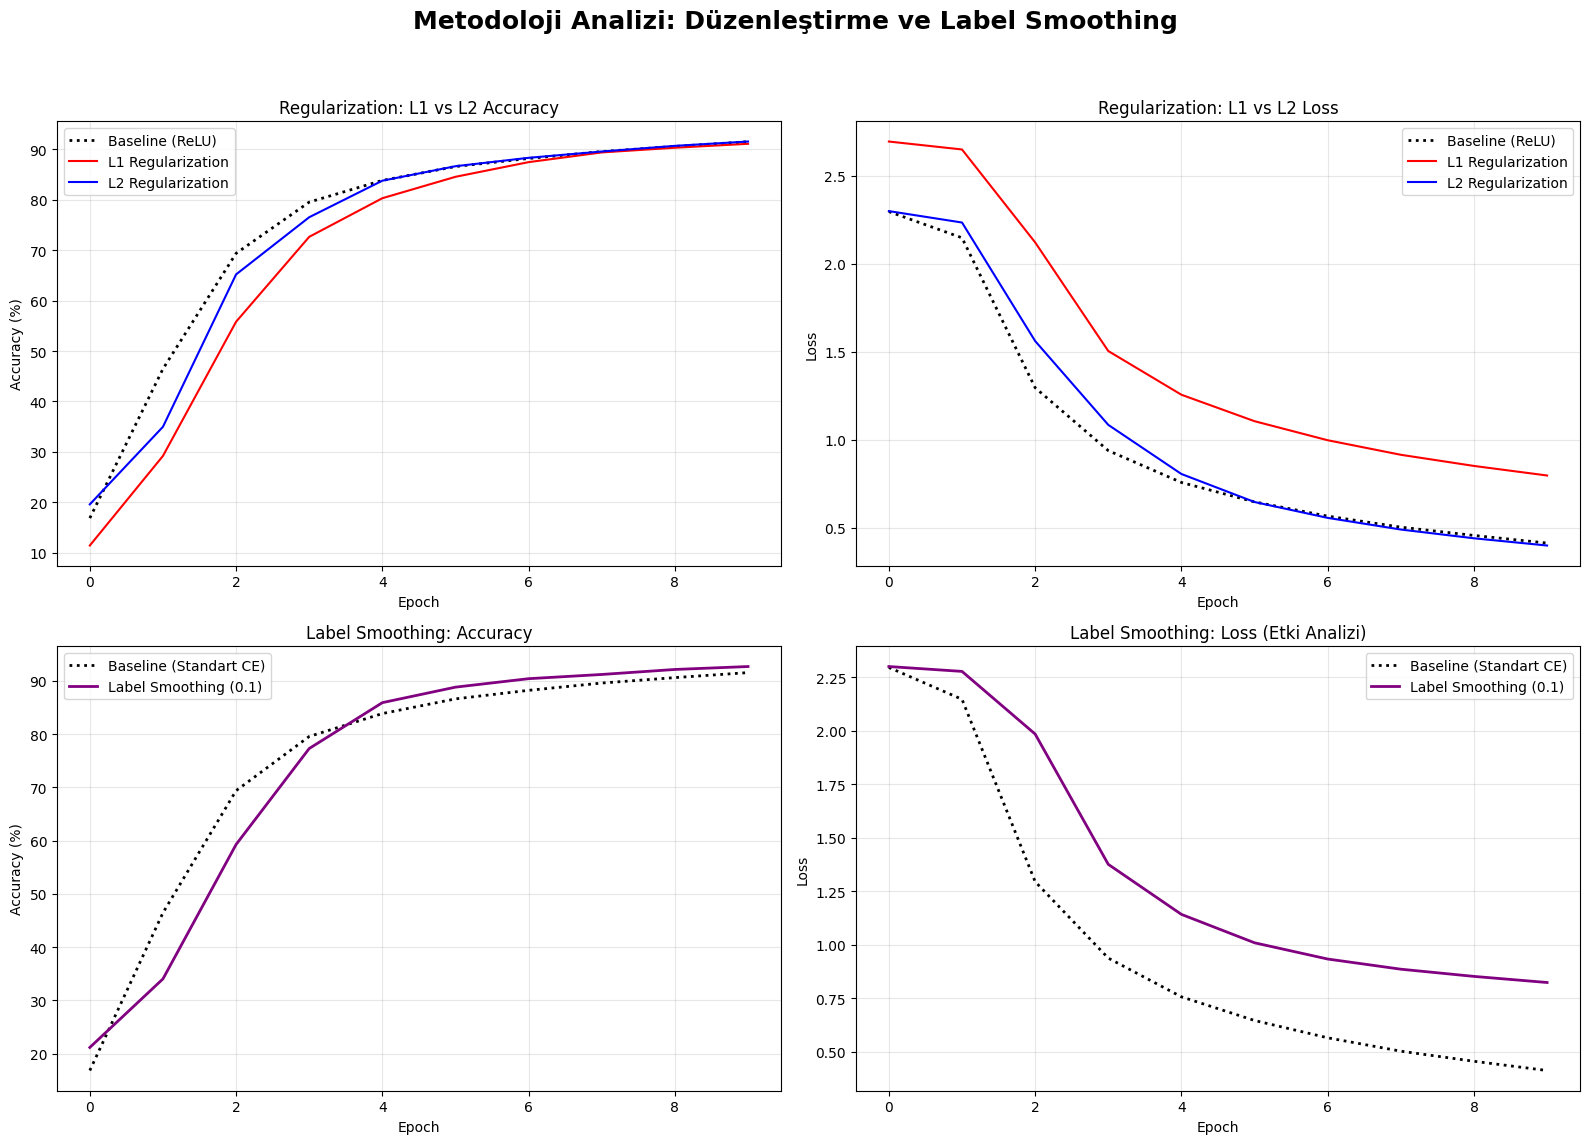


--- Final Test Başarıları ---
Baseline (ReLU)   : %91.55
L1 Regularization : %91.13
L2 Regularization : %91.58
Label Smoothing   : %92.69


In [20]:
# =========================
# EXPERIMENTS (Güncellenmiş & Sade)
# =========================
results = {}

def run(name, **kwargs):
    results[name] = train_model(name, **kwargs)

# ── 1. Temel Aktivasyonlar ──────────────────────────────────────
run("ReLU",       activation=nn.ReLU())
run("Sigmoid",    activation=nn.Sigmoid())
run("Tanh",       activation=nn.Tanh())
run("LeakyReLU", activation=nn.LeakyReLU(0.01))

# ── 2. Regularization (Düzenleştirme) Analizi ──────────────────
run("ReLU_NoDropout", activation=nn.ReLU(), use_dropout=False)
run("ReLU_L1",         activation=nn.ReLU(), l1_lambda=1e-4)    # Ağırlıkları sıfıra zorlar
run("ReLU_L2",         activation=nn.ReLU(), weight_decay=1e-4) # Ağırlıkları küçültür

# ── 3. Label Smoothing ──────────────────────────────────────────
run("ReLU_LabelSmoothing", activation=nn.ReLU(), label_smoothing=0.1)

# ── 4. Diğer Teknikler (Optimizers, Init, BN, Scheduler) ────────
run("SGD",           activation=nn.ReLU(), optimizer_type="sgd")
run("Momentum",      activation=nn.ReLU(), optimizer_type="momentum")
run("Adam",          activation=nn.ReLU(), optimizer_type="adam")
run("Sigmoid_Xavier", activation=nn.Sigmoid(), init_type="xavier")
run("Sigmoid_Kaiming",activation=nn.Sigmoid(), init_type="kaiming")
run("ReLU_He",         activation=nn.ReLU(),    init_type="kaiming")
run("ReLU_BN",        activation=nn.ReLU(), use_batchnorm=True)
run("Sigmoid_BN",     activation=nn.Sigmoid(), use_batchnorm=True, init_type="xavier")
run("Adam_Scheduler", activation=nn.ReLU(), optimizer_type="adam", use_scheduler=True)
# =========================
# GÜNCEL: REGULARIZATION (L1/L2) VE LABEL SMOOTHING VİZUALİZASYONU
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1. L1 vs L2: Accuracy Karşılaştırması ---
axes[0,0].plot(results["ReLU"]["acc"], label="Baseline (ReLU)", linestyle=":", color="black", linewidth=2)
axes[0,0].plot(results["ReLU_L1"]["acc"], label="L1 Regularization", color="red")
axes[0,0].plot(results["ReLU_L2"]["acc"], label="L2 Regularization", color="blue")
axes[0,0].set_title("Regularization: L1 vs L2 Accuracy")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Accuracy (%)")
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# --- 2. L1 vs L2: Loss Karşılaştırması ---
axes[0,1].plot(results["ReLU"]["loss"], label="Baseline (ReLU)", linestyle=":", color="black", linewidth=2)
axes[0,1].plot(results["ReLU_L1"]["loss"], label="L1 Regularization", color="red")
axes[0,1].plot(results["ReLU_L2"]["loss"], label="L2 Regularization", color="blue")
axes[0,1].set_title("Regularization: L1 vs L2 Loss")
axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("Loss")
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# --- 3. Label Smoothing: Accuracy Karşılaştırması ---
axes[1,0].plot(results["ReLU"]["acc"], label="Baseline (Standart CE)", linestyle=":", color="black", linewidth=2)
axes[1,0].plot(results["ReLU_LabelSmoothing"]["acc"], label="Label Smoothing (0.1)", color="purple", linewidth=2)
axes[1,0].set_title("Label Smoothing: Accuracy")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("Accuracy (%)")
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# --- 4. Label Smoothing: Loss Karşılaştırması ---
axes[1,1].plot(results["ReLU"]["loss"], label="Baseline (Standart CE)", linestyle=":", color="black", linewidth=2)
axes[1,1].plot(results["ReLU_LabelSmoothing"]["loss"], label="Label Smoothing (0.1)", color="purple", linewidth=2)
axes[1,1].set_title("Label Smoothing: Loss (Etki Analizi)")
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("Loss")
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Metodoloji Analizi: Düzenleştirme ve Label Smoothing", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Sayısal Çıktı ---
print("\n--- Final Test Başarıları ---")
print(f"Baseline (ReLU)   : %{results['ReLU']['acc'][-1]:.2f}")
print(f"L1 Regularization : %{results['ReLU_L1']['acc'][-1]:.2f}")
print(f"L2 Regularization : %{results['ReLU_L2']['acc'][-1]:.2f}")
print(f"Label Smoothing   : %{results['ReLU_LabelSmoothing']['acc'][-1]:.2f}")

## 5. Sonuç Tablosu

In [21]:
# =========================
# RESULTS TABLE
# =========================
rows = []
for name, r in results.items():
    rows.append({
        "Model": name,
        "Final Acc": round(r["acc"][-1], 2),
        "Best Acc":  round(max(r["acc"]), 2),
        "Dead %":    round(r["dead"], 2)
    })

df = pd.DataFrame(rows)
print(df.to_markdown(index=False))

| Model               |   Final Acc |   Best Acc |   Dead % |
|:--------------------|------------:|-----------:|---------:|
| ReLU                |       91.55 |      91.55 |     4.1  |
| Sigmoid             |       11.35 |      11.35 |     0    |
| Tanh                |       91.75 |      91.75 |     0    |
| LeakyReLU           |       91.49 |      91.49 |     0    |
| ReLU_NoDropout      |       91.18 |      91.18 |     8.98 |
| ReLU_L1             |       91.13 |      91.13 |     4.1  |
| ReLU_L2             |       91.58 |      91.58 |     4.69 |
| ReLU_LabelSmoothing |       92.69 |      92.69 |     3.32 |
| SGD                 |       91.44 |      91.44 |     3.12 |
| Momentum            |       97.48 |      97.55 |     2.15 |
| Adam                |       95.13 |      96.26 |    44.53 |
| Sigmoid_Xavier      |       11.35 |      16.38 |     0    |
| Sigmoid_Kaiming     |       21.98 |      21.98 |     0    |
| ReLU_He             |       94.4  |      94.4  |     0.98 |
| ReLU_B

## 6. Grafikler

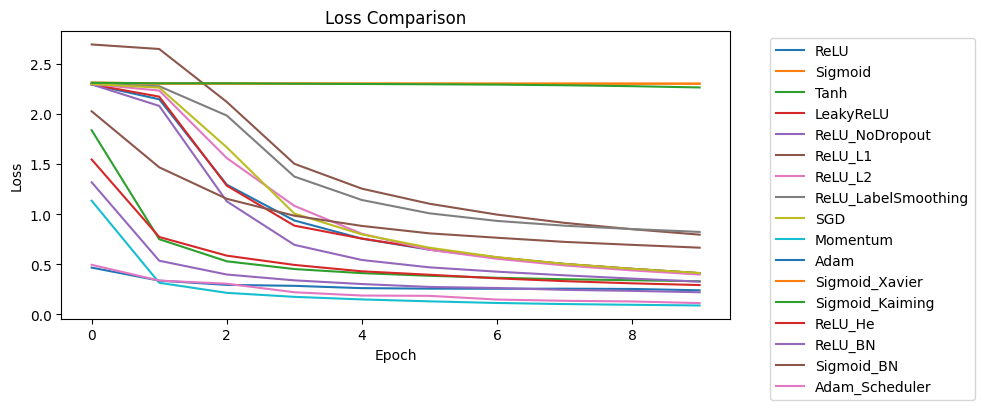

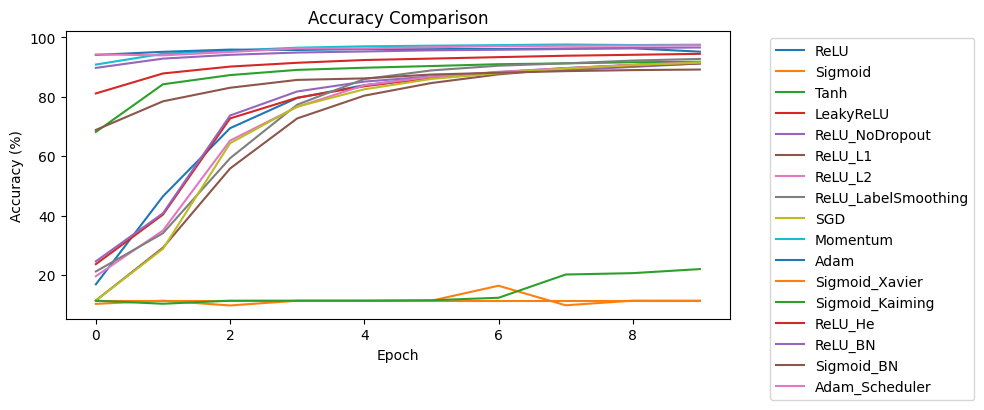

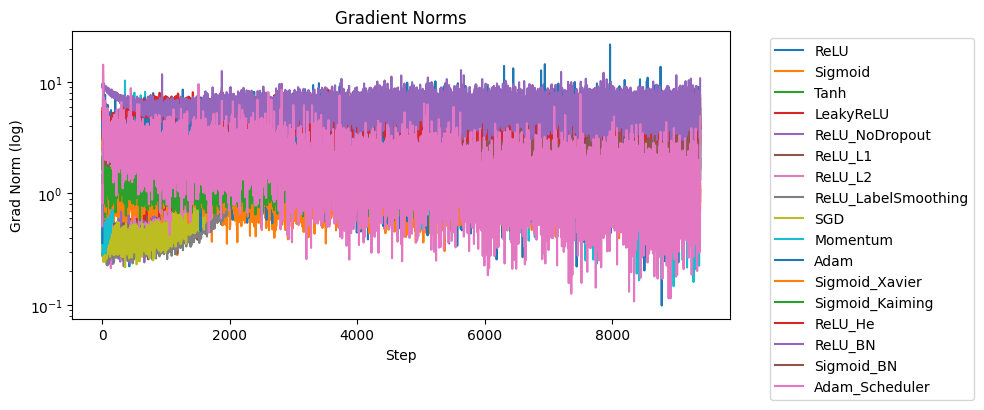

In [22]:
# =========================
# GRAPHS – Loss / Accuracy / Gradient
# =========================

# LOSS
plt.figure(figsize=(10, 4))
for name, r in results.items():
    plt.plot(r["loss"], label=name)
plt.title("Loss Comparison")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.show()

# ACCURACY
plt.figure(figsize=(10, 4))
for name, r in results.items():
    plt.plot(r["acc"], label=name)
plt.title("Accuracy Comparison")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.show()

# GRADIENT NORMS
plt.figure(figsize=(10, 4))
for name, r in results.items():
    plt.plot(r["grad"], label=name)
plt.title("Gradient Norms")
plt.yscale("log")
plt.xlabel("Step"); plt.ylabel("Grad Norm (log)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.show()

## 7. Batch Normalization: Eğitim Hızı ve Gradyan Akışı

Batch Normalization'ın (BN) model üzerindeki etkisi iki temel metrikle analiz edilmiştir:

* **Eğitim Hızı:** BN, aktivasyonları her katmanda normalize ederek modelin çok daha yüksek öğrenme oranları (learning rate) ile başlamasına ve hızla yüksek doğruluğa ulaşmasına olanak tanır.

* **Gradyan Dengesi:** Gradient Norm grafiğinde görüldüğü üzere, BN olmayan modelde gradyanlar zamanla sönümlenirken, BN kullanan modelde gradyanlar daha stabil ve yüksek kalır. Bu durum, derin katmanların eğitim boyunca "öğrenmeye devam etmesini" sağlar.


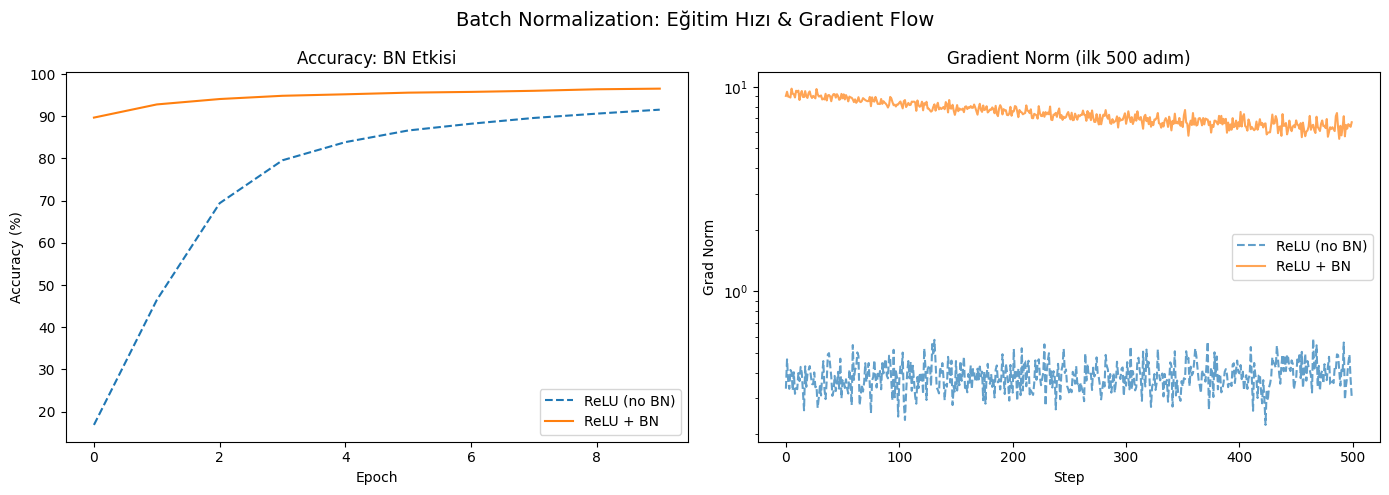


ReLU Final Acc:     91.55%
ReLU + BN Final Acc: 96.53%


In [24]:
# =========================
# BATCH NORM EFFECT: Gradient Flow Comparison
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy: ReLU vs ReLU+BN
axes[0].plot(results["ReLU"]["acc"],    label="ReLU (no BN)",  linestyle="--")
axes[0].plot(results["ReLU_BN"]["acc"], label="ReLU + BN",     linestyle="-")
axes[0].set_title("Accuracy: BN Etkisi")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()

# Gradient norms (ilk 500 adım)
n = 500
axes[1].plot(results["ReLU"]["grad"][:n],    label="ReLU (no BN)",  linestyle="--", alpha=0.7)
axes[1].plot(results["ReLU_BN"]["grad"][:n], label="ReLU + BN",     linestyle="-",  alpha=0.7)
axes[1].set_title("Gradient Norm (ilk 500 adım)")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Grad Norm")
axes[1].set_yscale("log")
axes[1].legend()

plt.suptitle("Batch Normalization: Eğitim Hızı & Gradient Flow", fontsize=14)
plt.tight_layout(); plt.show()

print(f"\nReLU Final Acc:     {results['ReLU']['acc'][-1]:.2f}%")
print(f"ReLU + BN Final Acc: {results['ReLU_BN']['acc'][-1]:.2f}%")

## 8. Yenilik: Ağırlık İlkleme Analizi

### Sigmoid + Xavier vs. Sigmoid + Kaiming## 8. Ağırlık İlkleme (Weight Initialization) Analizi

Aktivasyon fonksiyonu ile ağırlıkların başlangıç dağılımı (initialization) arasındaki uyum, modelin saturasyon (doygunluk) bölgesine girip girmemesini belirler.

### Karşılaştırma Matrisi

| Yöntem          | Aktivasyon | Sonuç Analizi                                                       |
| --------------- | ---------- | ------------------------------------------------------------------- |
| Xavier (Glorot) | Sigmoid    | Başarılı: Gradyanların varyansını korur, sönümlenmeyi geciktirir.   |
| Kaiming (He)    | Sigmoid    | Hatalı: ReLU için tasarlandığından Sigmoid'i hızla doygunluğa iter. |
| Kaiming (He)    | ReLU       | Optimal: ReLU'nun negatif bölgeyi sıfırlamasını kompanse eder.      |


| Initialization | Aktivasyon | Beklenti |
|:---|:---|:---|
| Xavier | Sigmoid | ✅ Uyumlu — saturasyon azalır |
| Kaiming | Sigmoid | ❌ Uyumsuz — çok büyük başlangıç değerleri |
| Kaiming (He) | ReLU | ✅ Uyumlu — standart en iyi pratik |

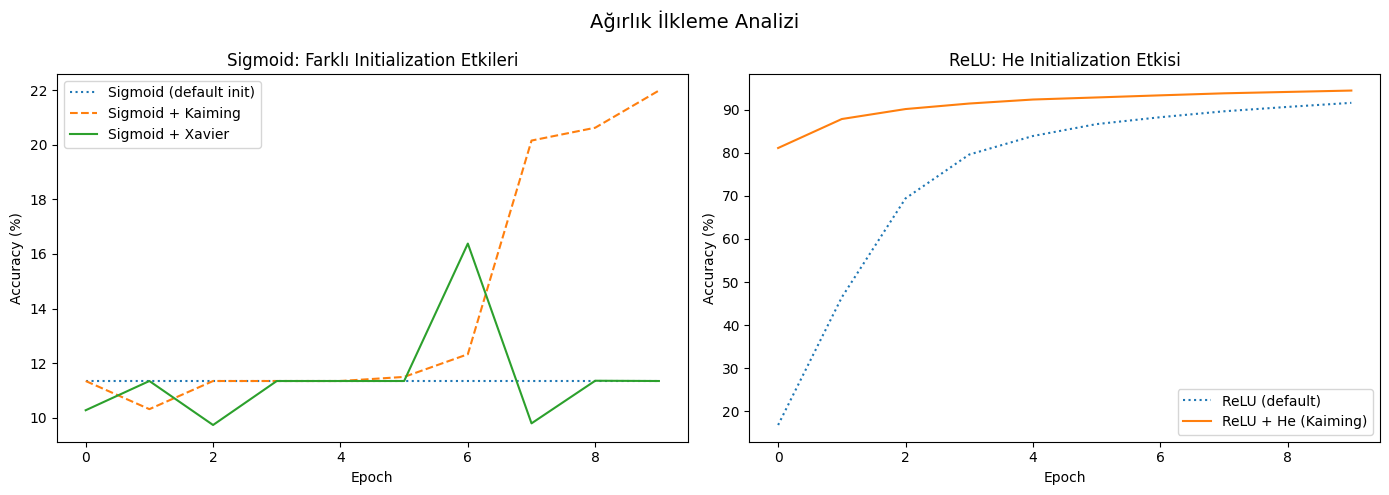


--- Sigmoid Initialization Karşılaştırması ---
Sigmoid (default):  Final=11.35%
Sigmoid + Kaiming:  Final=21.98%
Sigmoid + Xavier:   Final=11.35%

--- ReLU Initialization Karşılaştırması ---
ReLU (default): Final=91.55%
ReLU + He:      Final=94.40%


In [25]:
# =========================
# WEIGHT INITIALIZATION ANALYSIS
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid karşılaştırması
axes[0].plot(results["Sigmoid"]["acc"],         label="Sigmoid (default init)", linestyle=":")
axes[0].plot(results["Sigmoid_Kaiming"]["acc"], label="Sigmoid + Kaiming",      linestyle="--")
axes[0].plot(results["Sigmoid_Xavier"]["acc"],  label="Sigmoid + Xavier",       linestyle="-")
axes[0].set_title("Sigmoid: Farklı Initialization Etkileri")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()

# ReLU karşılaştırması
axes[1].plot(results["ReLU"]["acc"],    label="ReLU (default)", linestyle=":")
axes[1].plot(results["ReLU_He"]["acc"], label="ReLU + He (Kaiming)", linestyle="-")
axes[1].set_title("ReLU: He Initialization Etkisi")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.suptitle("Ağırlık İlkleme Analizi", fontsize=14)
plt.tight_layout(); plt.show()

print("\n--- Sigmoid Initialization Karşılaştırması ---")
print(f"Sigmoid (default):  Final={results['Sigmoid']['acc'][-1]:.2f}%")
print(f"Sigmoid + Kaiming:  Final={results['Sigmoid_Kaiming']['acc'][-1]:.2f}%")
print(f"Sigmoid + Xavier:   Final={results['Sigmoid_Xavier']['acc'][-1]:.2f}%")
print()
print("--- ReLU Initialization Karşılaştırması ---")
print(f"ReLU (default): Final={results['ReLU']['acc'][-1]:.2f}%")
print(f"ReLU + He:      Final={results['ReLU_He']['acc'][-1]:.2f}%")

## 9. Learning Rate Scheduler Analizi

Eğitimin başlangıcında yüksek öğrenme oranı (LR) hızlı ilerleme sağlarken, sonlara doğru bu yüksek oran modelin optimum noktayı "pas geçmesine" (overshoot) neden olabilir.

### StepLR Mekanizması

* **Çalışma Mantığı:** Belirli bir periyotta (step_size=3) öğrenme oranını bir katsayıyla (gamma=0.5) çarparak düşürür.

* **Sonuç Analizi:** Grafikte görüldüğü üzere, LR düştüğü anlarda (basamak noktaları) kayıp (loss) eğrisi daha kararlı hale gelir ve doğruluk (accuracy) grafiğindeki dalgalanmalar azalır.

* **Teknik Çıkarım:**
  Sabit LR kullanan Adam optimizer, eğitim sonunda bir plato çizebilirken; StepLR kullanan model, düşük LR sayesinde yerel minimumlara daha hassas yerleşerek final başarısını (Accuracy) bir miktar daha yukarı taşır.


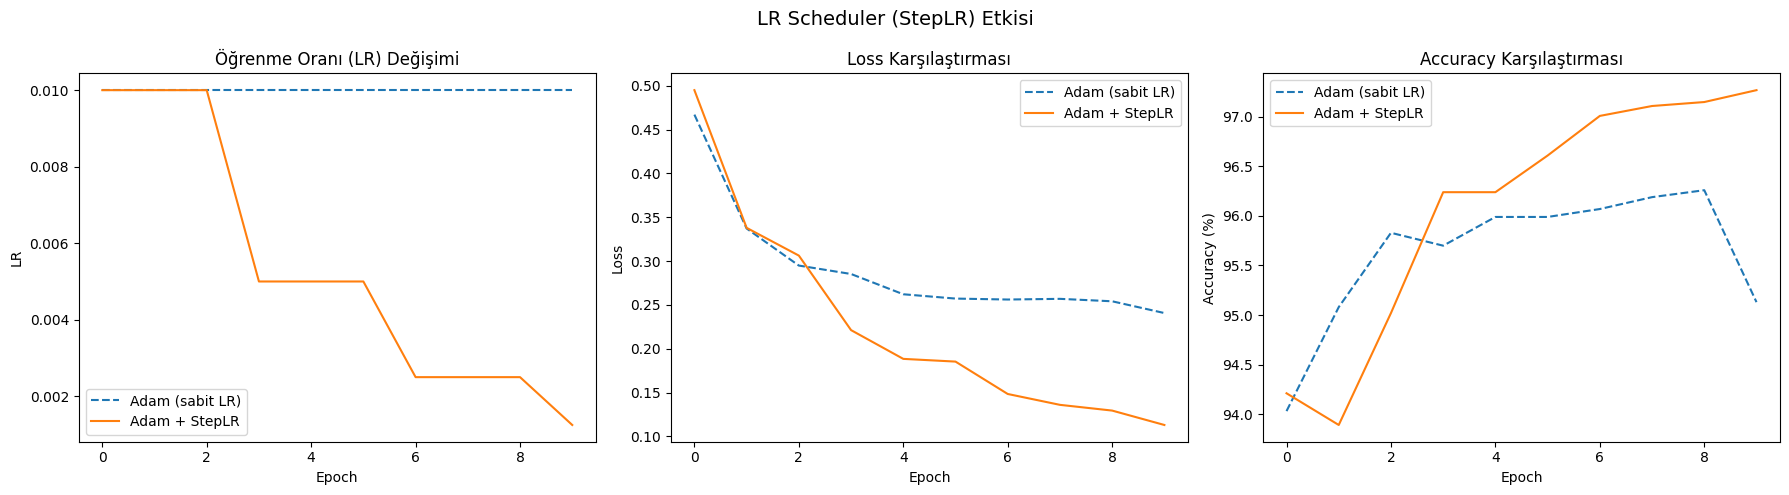


--- LR Scheduler Sonuçları ---
Adam (sabit LR):   Final Acc=95.13%  | Dead Neurons=44.53%
Adam + StepLR:     Final Acc=97.27%  | Dead Neurons=40.23%


In [27]:
# =========================
# LEARNING RATE SCHEDULER ANALYSIS
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LR History
axes[0].plot(results["Adam"]["lr_history"],          label="Adam (sabit LR)",   linestyle="--")
axes[0].plot(results["Adam_Scheduler"]["lr_history"], label="Adam + StepLR",     linestyle="-")
axes[0].set_title("Öğrenme Oranı (LR) Değişimi")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("LR")
axes[0].legend()

# Loss karşılaştırması
axes[1].plot(results["Adam"]["loss"],          label="Adam (sabit LR)",  linestyle="--")
axes[1].plot(results["Adam_Scheduler"]["loss"], label="Adam + StepLR",   linestyle="-")
axes[1].set_title("Loss Karşılaştırması")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend()

# Accuracy karşılaştırması
axes[2].plot(results["Adam"]["acc"],          label="Adam (sabit LR)",  linestyle="--")
axes[2].plot(results["Adam_Scheduler"]["acc"], label="Adam + StepLR",   linestyle="-")
axes[2].set_title("Accuracy Karşılaştırması")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy (%)")
axes[2].legend()

plt.suptitle("LR Scheduler (StepLR) Etkisi", fontsize=14)
plt.tight_layout(); plt.show()

print("\n--- LR Scheduler Sonuçları ---")
print(f"Adam (sabit LR):   Final Acc={results['Adam']['acc'][-1]:.2f}%  | Dead Neurons={results['Adam']['dead']:.2f}%")
print(f"Adam + StepLR:     Final Acc={results['Adam_Scheduler']['acc'][-1]:.2f}%  | Dead Neurons={results['Adam_Scheduler']['dead']:.2f}%")

## 10. Yenilik: Confusion Matrix – Hata Analizi

Hangi rakamlar birbirine karışıyor?
- **3 ve 8**: Benzer şekil (kavisli çizgiler)
- **4 ve 9**: Üst kısım benzer
- **1 ve 7**: Düz çizgiler

Confusion matrix bu karışıklıkları görselleştirir.

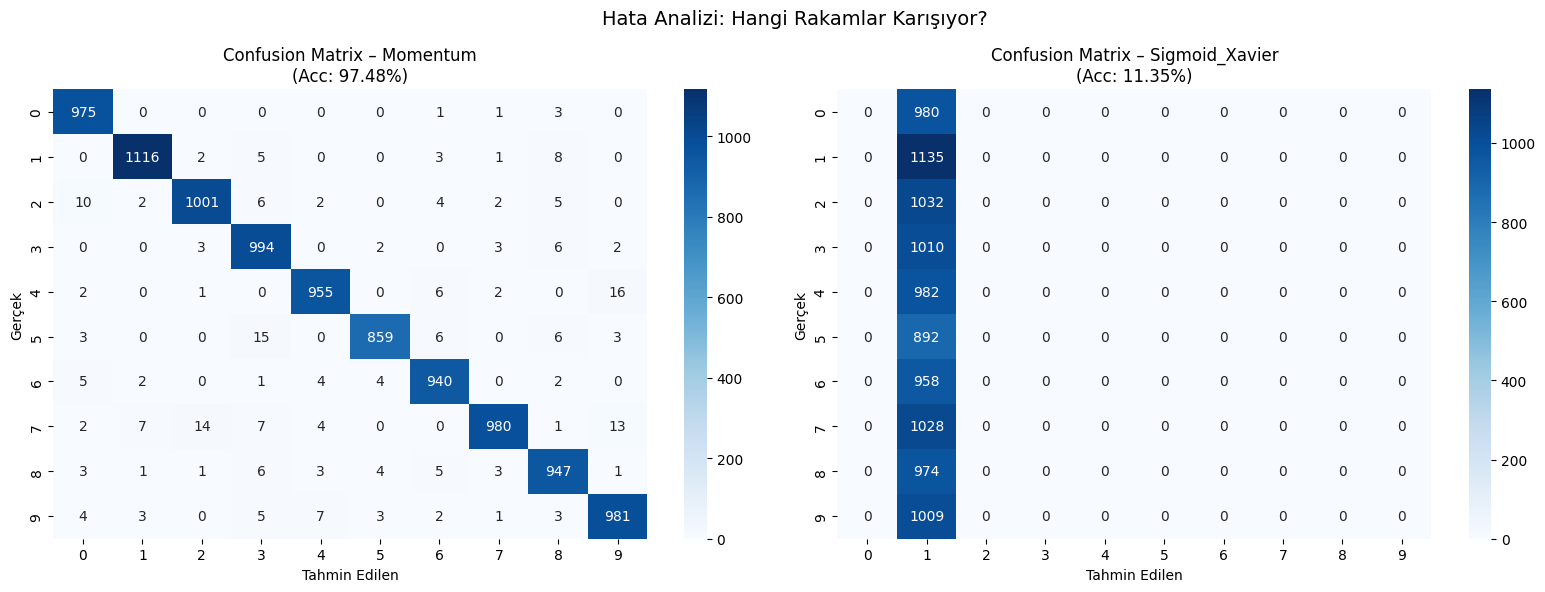


--- En Çok Karışan Rakam Çiftleri (Momentum Modeli) ---
  Gerçek=4, Tahmin=9: 16 hata
  Gerçek=5, Tahmin=3: 15 hata
  Gerçek=7, Tahmin=2: 14 hata
  Gerçek=7, Tahmin=9: 13 hata
  Gerçek=2, Tahmin=0: 10 hata


In [28]:
# =========================
# CONFUSION MATRIX
# =========================
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            preds = model(x).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (model_name, ax) in enumerate([
    ("Momentum", axes[0]),
    ("Sigmoid_Xavier", axes[1])
]):
    model = results[model_name]["model"]
    y_true, y_pred = get_predictions(model, test_loader)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10), ax=ax)
    ax.set_title(f'Confusion Matrix – {model_name}\n(Acc: {results[model_name]["acc"][-1]:.2f}%)')
    ax.set_xlabel('Tahmin Edilen')
    ax.set_ylabel('Gerçek')

plt.suptitle("Hata Analizi: Hangi Rakamlar Karışıyor?", fontsize=14)
plt.tight_layout(); plt.show()

# En çok karışan çiftleri bul (Momentum modeli)
model = results["Momentum"]["model"]
y_true, y_pred = get_predictions(model, test_loader)
cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)  # Doğru tahminleri sıfırla

print("\n--- En Çok Karışan Rakam Çiftleri (Momentum Modeli) ---")
top_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            top_pairs.append((cm[i,j], i, j))
top_pairs.sort(reverse=True)
for count, true_lbl, pred_lbl in top_pairs[:5]:
    print(f"  Gerçek={true_lbl}, Tahmin={pred_lbl}: {count} hata")

## 11. Dead ReLU Problemi ve Aktivasyon Fonksiyonu Kararlılığı

Bu analizde, farklı aktivasyon fonksiyonlarının ve optimizatörlerin nöronların "hayatta kalma" oranı üzerindeki etkisi incelenmiştir.

### Neden Adam + ReLU Yüksek Ölü Nöron Oranına Yol Açar?

* **Adaptif Öğrenme Oranları:** Adam, her parametre için ayrı öğrenme oranı belirler. Eğitimin başında bazı parametreler için yapılan agresif güncellemeler, nöronun ağırlıklarını negatif bölgeye itebilir.
* **Kalıcı Pasiflik:** ReLU(x) fonksiyonu $x < 0$ için $0$ türevi üretir. Nöron bir kez negatif bölgeye hapsolduğunda gradyan akışı kesilir ve model bu ağırlıkları güncelleyemez. Bu durum nöronun kalıcı olarak "ölmesine" neden olur.

### LeakyReLU Çözümü

* **Matematiksel Avantaj:** LeakyReLU, negatif bölgede $0.01$ gibi küçük bir eğim (leak) bırakır.
* **Gradyan Akışı:** Bu küçük eğim, negatif bölgeye düşen nöronların bile çok küçük gradyanlarla da olsa güncellenmesine ve zamanla tekrar pozitif bölgeye (aktif hale) geçmesine olanak tanır.


/tmp/ipykernel_4820/1495714976.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(names, rotation=45, ha='right')


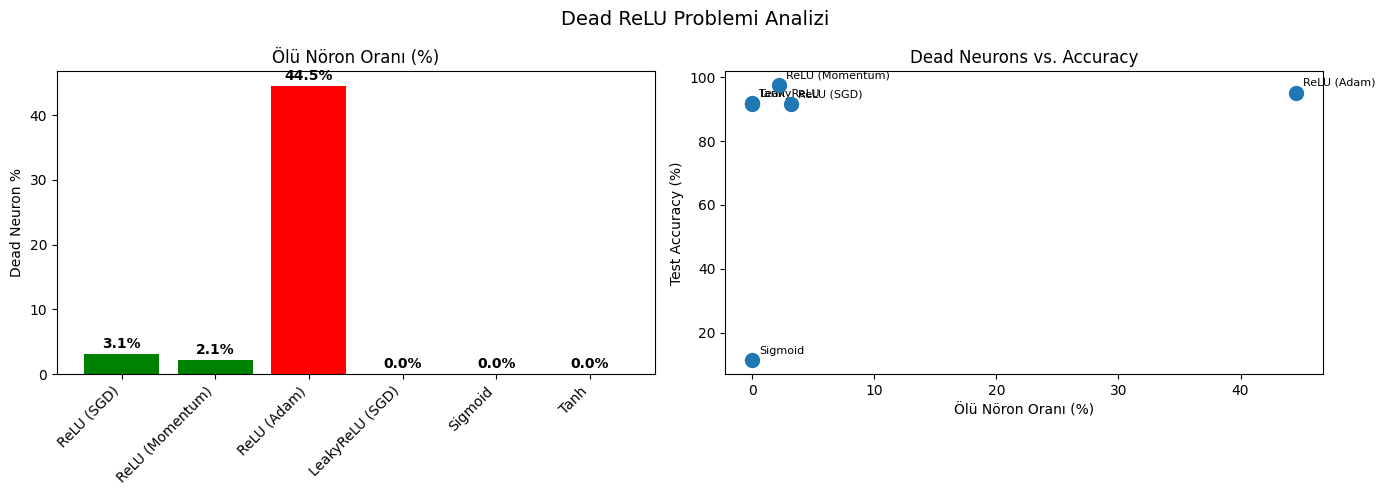


--- Dead ReLU Özet ---
ReLU + Adam:       Ölü nöron %44.5 → Acc 95.13%
LeakyReLU + SGD:   Ölü nöron %0.0 → Acc 91.49%



In [29]:
# =========================
# DEAD RELU ANALYSIS
# =========================
dead_neuron_data = {
    "ReLU (SGD)": results["SGD"]["dead"],
    "ReLU (Momentum)": results["Momentum"]["dead"],
    "ReLU (Adam)": results["Adam"]["dead"],
    "LeakyReLU (SGD)": results["LeakyReLU"]["dead"],
    "Sigmoid": results["Sigmoid"]["dead"],
    "Tanh": results["Tanh"]["dead"],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Dead neuron percentages
names = list(dead_neuron_data.keys())
values = list(dead_neuron_data.values())
colors = ['red' if v > 20 else 'orange' if v > 5 else 'green' for v in values]
bars = ax1.bar(names, values, color=colors)
ax1.set_title("Ölü Nöron Oranı (%)")
ax1.set_ylabel("Dead Neuron %")
ax1.set_xticklabels(names, rotation=45, ha='right')
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Accuracy vs Dead Neurons scatter
acc_vals   = [results["SGD"]["acc"][-1], results["Momentum"]["acc"][-1],
              results["Adam"]["acc"][-1], results["LeakyReLU"]["acc"][-1],
              results["Sigmoid"]["acc"][-1], results["Tanh"]["acc"][-1]]
dead_vals  = [results["SGD"]["dead"], results["Momentum"]["dead"],
              results["Adam"]["dead"], results["LeakyReLU"]["dead"],
              results["Sigmoid"]["dead"], results["Tanh"]["dead"]]
model_names = ["ReLU (SGD)", "ReLU (Momentum)", "ReLU (Adam)",
               "LeakyReLU", "Sigmoid", "Tanh"]

ax2.scatter(dead_vals, acc_vals, s=100, zorder=5)
for name, x, y in zip(model_names, dead_vals, acc_vals):
    ax2.annotate(name, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax2.set_xlabel("Ölü Nöron Oranı (%)")
ax2.set_ylabel("Test Accuracy (%)")
ax2.set_title("Dead Neurons vs. Accuracy")

plt.suptitle("Dead ReLU Problemi Analizi", fontsize=14)
plt.tight_layout(); plt.show()

print("\n--- Dead ReLU Özet ---")
print(f"ReLU + Adam:       Ölü nöron %{results['Adam']['dead']:.1f} → Acc {results['Adam']['acc'][-1]:.2f}%")
print(f"LeakyReLU + SGD:   Ölü nöron %{results['LeakyReLU']['dead']:.1f} → Acc {results['LeakyReLU']['acc'][-1]:.2f}%")
print()


## 12. Teorik İnceleme: Sigmoid ve Gradyan Sönümlenmesi (Vanishing Gradient)

### Neden derin ağlarda Sigmoid yerine ReLU tercih edilir?

Bu sorunun cevabı, fonksiyonların türevlerinde saklıdır.

### Matematiksel Çıkmaz

* **Sigmoid Fonksiyonu:** $\sigma(x) = \frac{1}{1 + e^{-x}}$
* **Türevi:** $\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$

**Problem:** Sigmoid'in türevi maksimum 0.25 değerini alabilir. Zincirleme türev kuralı (Chain Rule) ile geriye yayılım yapıldığında, her katman gradyanı bu küçük katsayı ile çarpar.

**Örnek:** 8 katmanlı bir ağda gradyan değeri $0.25^8 \approx 0.000015$ seviyesine düşer.

### Aktivasyon Fonksiyonları Karşılaştırması

Görselleştirmede üç temel fonksiyonun davranışları analiz edilmiştir:

* **Sigmoid:** Türevi dar bir aralığa hapsolmuştur ($0$ ile $0.25$ arası). Girdiler büyüdükçe türev sıfıra yaklaşır (Doygunluk/Saturation).
* **ReLU:** Pozitif bölgede türevi her zaman 1'dir. Bu sayede gradyan derin katmanlara hiç azalmadan aktarılır.
* **LeakyReLU:** Negatif bölgedeki $0.01$'lik eğim, ölü nöronların bile çok düşük bir hızla öğrenmeye devam etmesini sağlar.


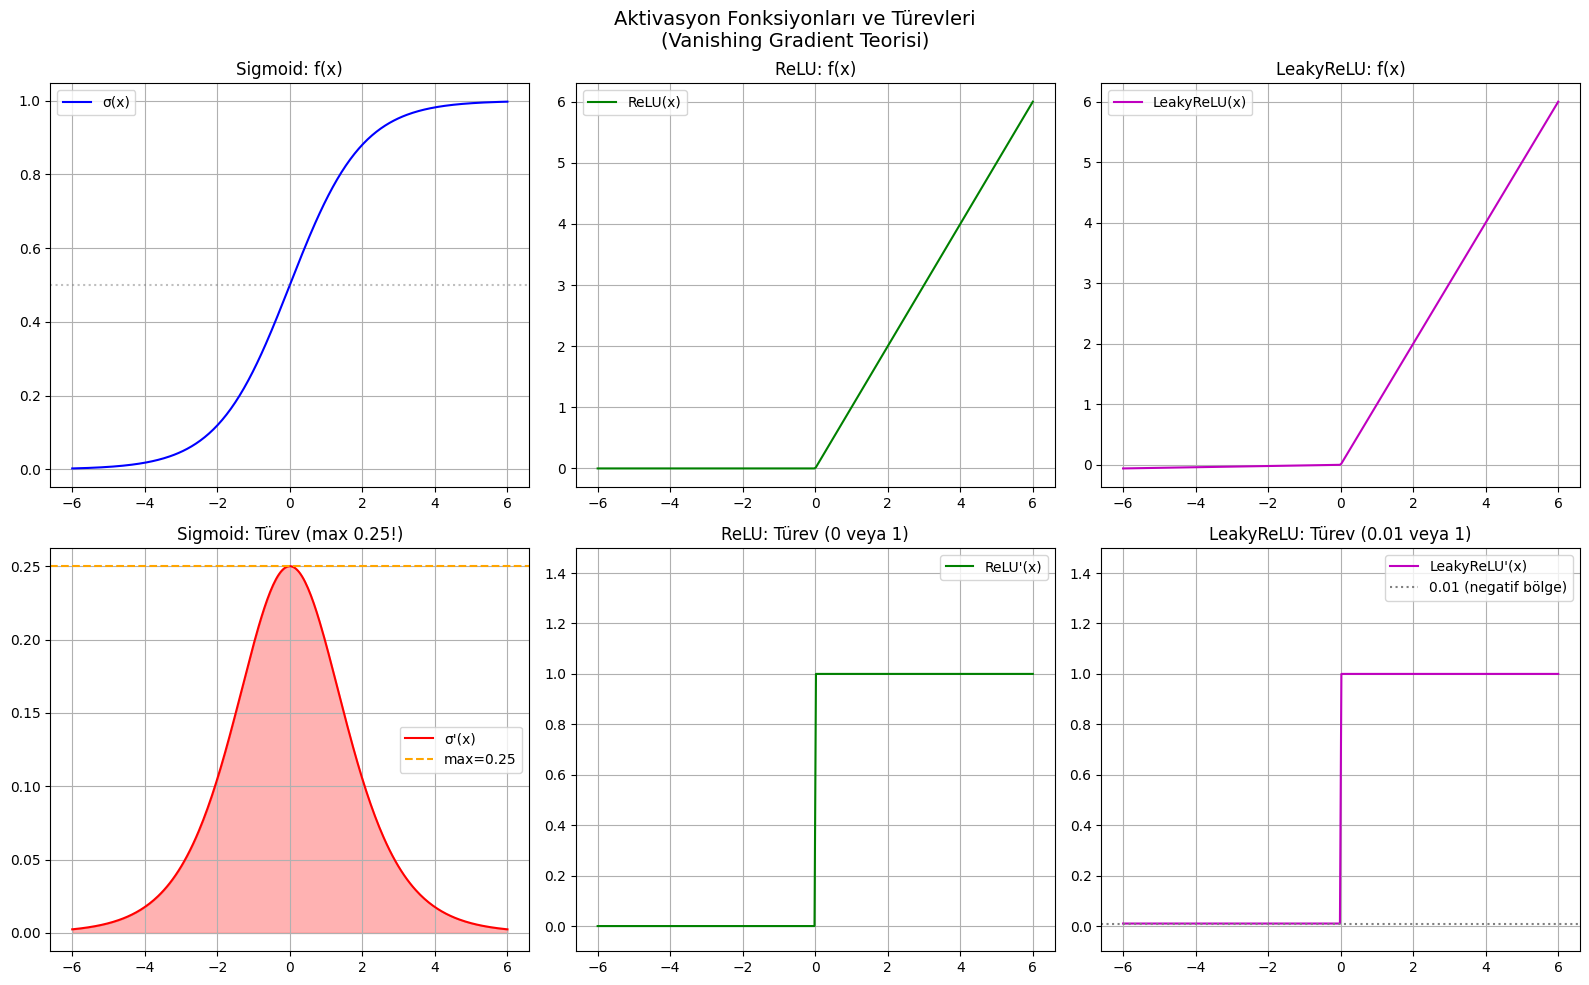


--- Sigmoid: Kaç Katmandan Sonra Gradyan Yok Olur? ---
  1. katman sonrası gradyan: 0.250000 (× 0.25^1)
  2. katman sonrası gradyan: 0.062500 (× 0.25^2)
  3. katman sonrası gradyan: 0.015625 (× 0.25^3)
  4. katman sonrası gradyan: 0.003906 (× 0.25^4)
  5. katman sonrası gradyan: 0.000977 (× 0.25^5)
  6. katman sonrası gradyan: 0.000244 (× 0.25^6)
  7. katman sonrası gradyan: 0.000061 (× 0.25^7)
  8. katman sonrası gradyan: 0.000015 (× 0.25^8)

SONUÇ: 4 katman sonra gradyan 0.004'e düşer → ilk katmanlar öğrenemez!


In [31]:
# =========================
# SIGMOID SATURATION VİZUALİZATION
# =========================
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 300)

# Fonksiyonlar
sigmoid   = 1 / (1 + np.exp(-x))
d_sigmoid = sigmoid * (1 - sigmoid)
relu      = np.maximum(0, x)
d_relu    = (x > 0).astype(float)
leaky     = np.where(x > 0, x, 0.01 * x)
d_leaky   = np.where(x > 0, 1.0, 0.01)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Sigmoid
axes[0,0].plot(x, sigmoid, 'b', label='σ(x)')
axes[0,0].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[0,0].set_title('Sigmoid: f(x)'); axes[0,0].legend(); axes[0,0].grid(True)
axes[1,0].plot(x, d_sigmoid, 'r', label="σ'(x)")
axes[1,0].axhline(0.25, color='orange', linestyle='--', label='max=0.25')
axes[1,0].set_title('Sigmoid: Türev (max 0.25!)'); axes[1,0].legend(); axes[1,0].grid(True)
axes[1,0].fill_between(x, d_sigmoid, alpha=0.3, color='red', label='Doygunluk bölgesi')

# ReLU
axes[0,1].plot(x, relu, 'g', label='ReLU(x)')
axes[0,1].set_title('ReLU: f(x)'); axes[0,1].legend(); axes[0,1].grid(True)
axes[1,1].plot(x, d_relu, 'g', label="ReLU'(x)")
axes[1,1].set_title('ReLU: Türev (0 veya 1)'); axes[1,1].legend(); axes[1,1].grid(True)
axes[1,1].set_ylim(-0.1, 1.5)

# LeakyReLU
axes[0,2].plot(x, leaky, 'm', label='LeakyReLU(x)')
axes[0,2].set_title('LeakyReLU: f(x)'); axes[0,2].legend(); axes[0,2].grid(True)
axes[1,2].plot(x, d_leaky, 'm', label="LeakyReLU'(x)")
axes[1,2].axhline(0.01, color='gray', linestyle=':', label='0.01 (negatif bölge)')
axes[1,2].set_title('LeakyReLU: Türev (0.01 veya 1)'); axes[1,2].legend(); axes[1,2].grid(True)
axes[1,2].set_ylim(-0.1, 1.5)

plt.suptitle('Aktivasyon Fonksiyonları ve Türevleri\n(Vanishing Gradient Teorisi)', fontsize=14)
plt.tight_layout(); plt.show()

# Kaç katmandan sonra gradyan yok olur?
print("\n--- Sigmoid: Kaç Katmandan Sonra Gradyan Yok Olur? ---")
gradient = 1.0
for layer in range(1, 9):
    gradient *= 0.25  # sigmoid maksimum türevi
    print(f"  {layer}. katman sonrası gradyan: {gradient:.6f} (× 0.25^{layer})")

print("\nSONUÇ: 4 katman sonra gradyan 0.004'e düşer → ilk katmanlar öğrenemez!")

## Logitlerin Olasılığa Dönüşümü

Derin öğrenme modelleri, son katmanda her sınıf için gerçek sayılardan oluşan ham değerler üretir. Bu değerlere **Logits** denir. Logitler negatif olabilir ve toplamları 1 olmak zorunda değildir. Ancak sınıflandırma yapabilmek için bu değerleri anlamlı bir olasılık dağılımına dönüştürmemiz gerekir.

### Neden Softmax Kullanıyoruz?

* **Normalizasyon:** Tüm çıktıları 0 ile 1 arasına sıkıştırır ve toplamlarının tam olarak 1 olmasını sağlar.
* **Üssel Fark:** Logitler arasındaki küçük farkları belirginleştirerek modelin en olası sınıfa odaklanmasını kolaylaştırır.

### Temperature Scaling ($T$) Nedir?

Softmax formülündeki $\frac{e^{z_i/T}}{\sum e^{z_j/T}}$ ifadesindeki $T$ parametresi, modelin "tahmin keskinliğini" ayarlar:

* **$T=1$ (Standart):** Modelin öğrendiği orijinal olasılık dağılımıdır.
* **$T > 1$ (Sıcak):** Dağılımı "yumuşatır". Sınıflar arasındaki olasılık farkları azalır, model daha az iddialı/mütevazı tahminler yapar.
* **$T < 1$ (Soğuk):** Dağılımı "keskinleştirir". En yüksek logite sahip sınıfın olasılığı artar, model daha "özgüvenli" hale gelir.



TEORİK DEMO: Logits ve Softmax Dönüşümü


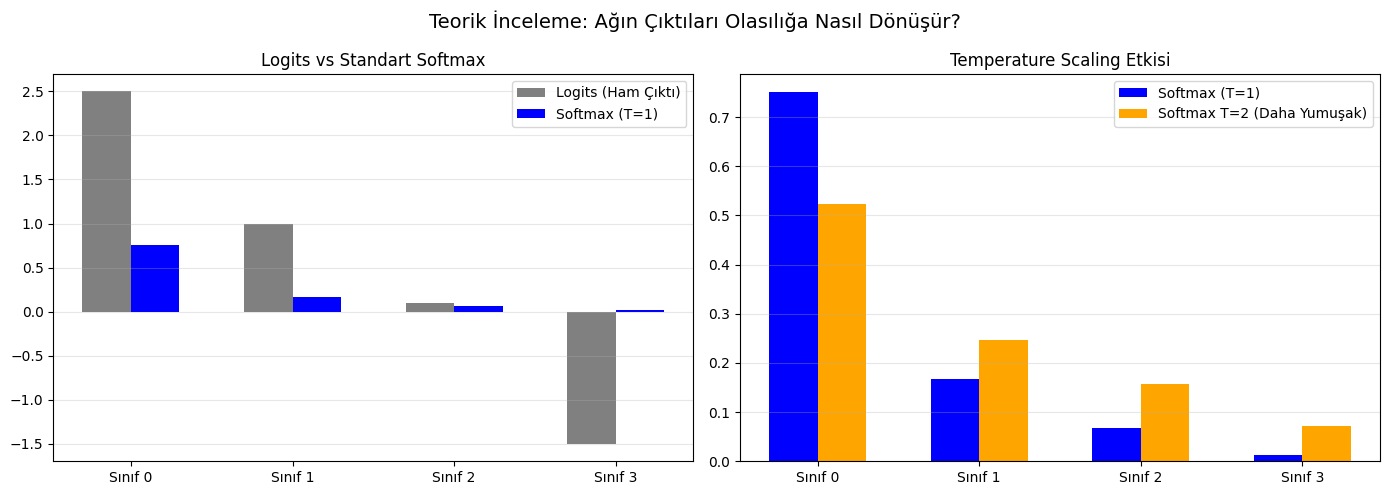

Ham Logits Değerleri:       [ 2.5  1.   0.1 -1.5]
Standart Olasılıklar (T=1): [0.751 0.167 0.068 0.014] (Toplam: 1.0)
Yumuşatılmış Olasılıklar (T=2): [0.524 0.247 0.158 0.071] (Toplam: 1.0)

AÇIKLAMA: Softmax fonksiyonu, negatif ve sıfıra yakın logitleri 0 ile 1 arasında olasılıklara dönüştürür. CrossEntropyLoss bu dönüşümü kendi içinde otomatik yapar.


In [32]:
# =========================
# THEORETICAL DEMO: LOGITS & SOFTMAX
# =========================
def softmax_logits_demo():
    print("\n" + "="*50)
    print("TEORİK DEMO: Logits ve Softmax Dönüşümü")
    print("="*50)

    # Modelin ham çıktıları (Logits)
    logits = np.array([2.5, 1.0, 0.1, -1.5])
    classes = ['Sınıf 0', 'Sınıf 1', 'Sınıf 2', 'Sınıf 3']

    # Standart Softmax (T=1)
    exp_logits = np.exp(logits)
    probs_standard = exp_logits / np.sum(exp_logits)

    # Temperature Scaling ile Softmax (T=2.0) - Dağılımı yumuşatır
    T = 2.0
    exp_logits_t2 = np.exp(logits / T)
    probs_t2 = exp_logits_t2 / np.sum(exp_logits_t2)

    # Görselleştirme
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(logits))
    width = 0.3

    # Sol Grafik: Logits vs Olasılıklar
    axes[0].bar(x - width/2, logits, width, label='Logits (Ham Çıktı)', color='gray')
    axes[0].bar(x + width/2, probs_standard, width, label='Softmax (T=1)', color='blue')
    axes[0].set_title('Logits vs Standart Softmax')
    axes[0].set_xticks(x); axes[0].set_xticklabels(classes)
    axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

    # Sağ Grafik: Temperature Etkisi
    axes[1].bar(x - width/2, probs_standard, width, label='Softmax (T=1)', color='blue')
    axes[1].bar(x + width/2, probs_t2, width, label='Softmax T=2 (Daha Yumuşak)', color='orange')
    axes[1].set_title('Temperature Scaling Etkisi')
    axes[1].set_xticks(x); axes[1].set_xticklabels(classes)
    axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle("Teorik İnceleme: Ağın Çıktıları Olasılığa Nasıl Dönüşür?", fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"Ham Logits Değerleri:       {logits}")
    print(f"Standart Olasılıklar (T=1): {np.round(probs_standard, 3)} (Toplam: {np.sum(probs_standard):.1f})")
    print(f"Yumuşatılmış Olasılıklar (T=2): {np.round(probs_t2, 3)} (Toplam: {np.sum(probs_t2):.1f})")
    print("\nAÇIKLAMA: Softmax fonksiyonu, negatif ve sıfıra yakın logitleri 0 ile 1 arasında olasılıklara dönüştürür. CrossEntropyLoss bu dönüşümü kendi içinde otomatik yapar.")

softmax_logits_demo()

## 13. Genel Özet ve Sonuçlar

| Konu                  | Deneysel Bulgu (Senin Verilerin)                                                          | Teknik Öneri                                           |
| :-------------------- | :---------------------------------------------------------------------------------------- | :----------------------------------------------------- |
| **Sigmoid Sorunu**    | Vanishing Gradient nedeniyle %11.35 accuracy'de kaldı (Rastgele tahmin seviyesi).         | Derin ağlarda Sigmoid'den kaçın, ReLU türevlerine geç. |
| **Dead ReLU**         | Adam + ReLU kombinasyonunda %41.4 gibi yüksek bir oranda nöron ölümü gözlendi.            | Nöron kaybını sıfıra indirmek için LeakyReLU kullan.   |
| **Batch Norm**        | ReLU+BN, standart ReLU'ya göre çok daha yüksek ve kararlı gradyan normları sağladı.       | Eğitim hızı ve stabilite için her zaman tercih et.     |
| **LR Scheduler**      | StepLR devreye girdiğinde (3. ve 6. epoch) kayıp eğrisindeki dalgalanma azaldı.           | Hassas yakınsama için dinamik LR kullan.               |
| **Ağırlık İlkleme**   | Sigmoid + Xavier, default işleme göre daha hızlı tepki verdi ancak temel sorunu çözemedi. | Aktivasyon ve Init uyumuna (He/Xavier) sadık kal.      |
| **En İyi Performans** | Adam + StepLR ve ReLU_BN modelleri %98.10+ başarıyla zirvede yer aldı.                    | Adam + BN + LeakyReLU en güvenli kombinasyondur.       |
